Hola **Francia**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

El propósito principal de este proyecto es ayudar al departamento comercial de Megaline a identificar cuál de sus dos tarifas de prepago —Surf o Ultimate— es más rentable, con el fin de tomar decisiones estratégicas sobre cómo distribuir su presupuesto publicitario de manera más efectiva.

Acciones que planeo realizar:
1. Exploración y limpieza de datos: 
* Revisar los datos de los 500 clientes.
* Detectar y tratar valores ausentes o inconsistentes.
* Asegurar que los tipos de datos sean correctos para el análisis.

2. Transformación de datos:
* Unificar las unidades de medida (por ejemplo, minutos redondeados).
* Calcular el ingreso mensual generado por cada cliente según su tarifa.
* Agrupar los datos por mes y por tipo de tarifa para hacer comparaciones válidas.

3. Análisis del comportamiento del cliente:
* Examinar el uso promedio mensual de llamadas, mensajes de texto y datos móviles.
* Comparar el comportamiento entre los usuarios de Surf y Ultimate.

4. Comparación de ingresos:
* Calcular el ingreso promedio mensual por usuario para cada tarifa.
* Comparar ingresos totales generados por cada tipo de tarifa.

5. Análisis estadístico:
* Usar pruebas estadísticas para verificar si las diferencias observadas en los ingresos son estadísticamente significativas.

6. Conclusiones y recomendaciones:
* Determinar cuál tarifa genera más ingresos.
* Proporcionar recomendaciones sobre en cuál tarifa enfocar los esfuerzos publicitarios.

## Inicialización

In [1]:
# Cargar todas las librerías

import math as mt
from math import factorial

import numpy as np
import pandas as pd

from scipy import stats as st
from scipy.stats import ttest_ind

import seaborn as sns
import matplotlib.pyplot as plt

## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Buen trabajo realizando la importación de librerías y carga de datos en celdas separadas, esto ayuda a que la lectura y seguimiento del notebook sea más amigable
</div>

## Preparar los datos

In [3]:
#Resvisamos la informacion general de la tabla Users y los 5 primeros datos de la misma
print("Tabla: users")
print(users.info())
print(users.head())

Tabla: users
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None
   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Tho

In [4]:
#Cambiamos el tipo de datos de las columnas reg_date y churn_date al tipo datetime ya que inciialmente esta como object y no nos dejaría realizar operaciones qeu se puedan requerir mas adelante
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])
print(users.dtypes)

user_id                int64
first_name            object
last_name             object
age                    int64
city                  object
reg_date      datetime64[ns]
plan                  object
churn_date    datetime64[ns]
dtype: object


In [5]:
#validamos si existen valores ausentes 
print("Valores nulos en users:")
print(users.isnull().sum())

Valores nulos en users:
user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64


In [6]:
#mostramos un resumen de informacion general de cada uno de los DF
print("Tabla: users")
print(users.info())

Tabla: users
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB
None


In [7]:
#Resvisamos la informacion general de la tabla plans y los 5 primeros datos de la misma
print("Tabla: plans")
print(plans.info())
print(plans.head())

Tabla: plans
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20     

In [8]:
#validamos si existen valores ausentes 
print("\nValores nulos en plans:")
print(plans.isnull().sum())


Valores nulos en plans:
messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb               0
usd_per_message          0
usd_per_minute           0
plan_name                0
dtype: int64


In [9]:
#Resvisamos la informacion general de la tabla calls y los 5 primeros datos de la misma
print("Tabla: calls")
print(calls.info())
print(calls.head())

Tabla: calls
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None
         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


In [10]:
#Cambiamos el tipo de datos de las columnas call_date y user_id al tipo datetime e int respectivamente para unificar tipo de datos con las otras tablas
calls['call_date'] = pd.to_datetime(calls['call_date'])
calls['user_id'] = calls['user_id'].astype(int)
print(calls.dtypes)

id                   object
user_id               int64
call_date    datetime64[ns]
duration            float64
dtype: object


In [11]:
#validamos si existen valores ausentes 
print("\nValores nulos en calls:")
print(calls.isnull().sum())


Valores nulos en calls:
id           0
user_id      0
call_date    0
duration     0
dtype: int64


In [12]:
#mostramos un resumen de informacion general del DF
print("\nTabla: calls")
print(calls.info())


Tabla: calls
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB
None


In [13]:
#Resvisamos la informacion general de la tabla messagess y los 5 primeros datos de la misma
print("Tabla: messages")
print(messages.info())
print(messages.head())

Tabla: messages
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None
         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


In [14]:
#Cambiamos el tipo de datos de la columna message_date al tipo datetime para unificar tipo de datos con las otras tablas
messages['message_date'] = pd.to_datetime(messages['message_date'])
print(calls.dtypes)

id                   object
user_id               int64
call_date    datetime64[ns]
duration            float64
dtype: object


In [15]:
#validamos si existen valores ausentes 
print("\nValores nulos en messages:")
print(messages.isnull().sum())


Valores nulos en messages:
id              0
user_id         0
message_date    0
dtype: int64


In [16]:
#mostramos un resumen de informacion general del DF
print("\nTabla: messages")
print(messages.info())


Tabla: messages
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB
None


In [17]:
#Resvisamos la informacion general de la tabla internet y los 5 primeros datos de la misma
print("Tabla: internet")
print(internet.info())
print(internet.head())

Tabla: internet
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None
         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22


In [18]:
#Cambiamos el tipo de datos de la columna session_date al tipo datetime para unificar tipo de datos con las otras tablas
internet['session_date'] = pd.to_datetime(internet['session_date'])
print(internet.dtypes)

id                      object
user_id                  int64
session_date    datetime64[ns]
mb_used                float64
dtype: object


In [19]:
#validamos si existen valores ausentes 
print("\nValores nulos en internet:")
print(internet.isnull().sum())


Valores nulos en internet:
id              0
user_id         0
session_date    0
mb_used         0
dtype: int64


In [20]:
#mostramos un resumen de informacion general del DF
print("\nTabla: internet")
print(internet.info())


Tabla: internet
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB
None


<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Tienes una sección dedicada a cada dataset, todos estos procesos deberías hacerlos en la respectiva sesión para mantener el órden del proyecto
</div>

## Tarifas

In [21]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
print(plans.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None


In [22]:
# Imprime una muestra de los datos para las tarifas
print(plans.head())

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


Descripcion de lo que veo:

1. Planes disponibles:
Hay dos planes: surf y ultimate.
* surf es más económico pero con menos beneficios.
* ultimate es más caro pero incluye muchos más recursos (llamadas, SMS, datos).

2. Precio mensual (usd_monthly_pay):
* surf: 20 USD/mes
* ultimate: 70 USD/mes

3.	Datos incluidos:
* surf: 15,360 MB (15 GB)
* ultimate: 30,720 MB (30 GB)

4.	Precio por exceso de consumo:
* surf cobra más por GB, SMS y minutos que ultimate.
* Esto hace que el plan ultimate sea más rentable para usuarios de alto consumo.

Se deben realizar ajustes con respecto al redondeo de cifras de la duracion de las llamadas, el total de MB/GB, adicionalmente se debe crear una columna que me permita saber si un usuario se encuentra activo o no

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Para estandarizar tus datos en una unidad de medida aquí deberías transformar la columna de mb_per_month_included a GB, ya que el precio está en usd por GB, así los cálculos más adelante serán más sencillos de realizar
</div>

## Corregir datos

In [23]:
#Creamos una nueva columna en el df para realizar el calculo de pasar gb_per_month_included a MB
plans['gb_per_month_included'] = plans['mb_per_month_included'] / 1024
print(plans.head())

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  \
0               20          10             0.03            0.03      surf   
1               70           7             0.01            0.01  ultimate   

   gb_per_month_included  
0                   15.0  
1                   30.0  


<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Aquí sólo deberías revisar lo relacionado al dataset de tarifas, tienes una sección para el resto
</div>

## Enriquecer los datos

In [24]:
#Renombramos la columna usd_monthly_pay de la tabla Plans ya que en la descripción original se menciona como usd_monthly_fee
plans.rename(columns={'usd_monthly_pay': 'usd_monthly_fee'}, inplace=True)
print(plans.head)

<bound method NDFrame.head of    messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_fee  usd_per_gb  usd_per_message  usd_per_minute plan_name  \
0               20          10             0.03            0.03      surf   
1               70           7             0.01            0.01  ultimate   

   gb_per_month_included  
0                   15.0  
1                   30.0  >


## Usuarios/as

In [25]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
print(users.info())

# Estadísticas descriptivas de las columnas numéricas
print(users.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB
None
           user_id         age
count   500.000000  500.000000
mean   1249.500000   45.486000
std     144.481833   16.972269
min    1000.000000   18.000000
25%    1124.750000   30.000000
50%    1249.500000   46.000000
75%    1374.250000   61.000000
max    1499.000000   75.000000


In [26]:
# Imprime una muestra de datos para usuarios
print(users.head())

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

    reg_date      plan churn_date  
0 2018-12-24  ultimate        NaT  
1 2018-08-13      surf        NaT  
2 2018-10-21      surf        NaT  
3 2018-01-28      surf        NaT  
4 2018-05-23      surf        NaT  


Descripcion de lo que veo - Informacion general:

Datos ausentes:
* La columna churn_date (fecha de cancelación) tiene 466 valores faltantes (NaT), lo cual es lógico: solo 34 usuarios cancelaron el servicio.
* No hay otros valores nulos.

Tipos de datos:
* Los tipos de datos son adecuados:
* Fechas (reg_date, churn_date) están correctamente en formato datetime64[ns].
* La columna is_active es tipo bool, lo cual es apropiado para representar si el usuario sigue activo.
* Datos como first_name, last_name, city y plan son tipo object, lo esperado para texto.
* La columna plan podría convertirse en category, ya que solo hay dos opciones (surf, ultimate), lo que optimiza memoria y facilita análisis.

Distribución de edad:
* Las edades varían de 18 a 75 años, con una media de 45.5 años y una desviación estándar de ~17 años.
* La muestra parece tener una buena diversidad de edades.

Descripcion de lo que veo - Muestra de datos:

Columnas clave:
* El campo plan contiene valores como surf y ultimate, lo cual concuerda con las tarifas descritas.
* El campo city incluye nombres largos y específicos (con "MSA"), lo cual puede requerir limpieza o normalización si se quiere analizar por ciudad o región.

Fechas de registro (reg_date):
* Todas las fechas de registro están dentro del año 2018, lo cual es coherente con la descripción del proyecto.

churn_date = NaT:
* Muchos usuarios no tienen una fecha de cancelación, lo cual indica que siguen activos.


Problemas y soluciones:
* Datos nulos en churn_date: siguen apareciendo pero para eso creamos la columna is_active y asi poder segmentar a usuarios activos e inactivos
* Columna plan como object: Convertir a category para análisis y eficiencia
* Nombres de ciudad largos: crear una nueva columna con el estado o región extraído (si es necesario para el analisis)

### Corregir los datos

In [27]:
# Convertir la columna plan a category, para mejorar analisis y eficiencia
users['plan'] = users['plan'].astype('category')
print(users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    category      
 7   churn_date  34 non-null     datetime64[ns]
dtypes: category(1), datetime64[ns](2), int64(2), object(3)
memory usage: 28.1+ KB
None


### Enriquecer los datos

In [28]:
#Verificar si hay duplicados en user_id
users['user_id'].duplicated().sum()
#columnas duplicadas
#users[users['user_id'].duplicated()]
#cuantos valores unicos hay en user_id (500: no hay duplicados)
#users['user_id'].nunique()

0

In [29]:
#Creamos una columna de estado del usuario (activo o no activo) según churn_date 
#para indicar que los usuarios con valor ausente en esta columna , son usuarios activos
users['is_active'] = users['churn_date'].isna()
print(users.head)

<bound method NDFrame.head of      user_id first_name   last_name  age  \
0       1000   Anamaria       Bauer   45   
1       1001     Mickey   Wilkerson   28   
2       1002     Carlee     Hoffman   36   
3       1003   Reynaldo     Jenkins   52   
4       1004    Leonila    Thompson   40   
..       ...        ...         ...  ...   
495     1495      Fidel      Sharpe   67   
496     1496      Ariel    Shepherd   49   
497     1497      Donte     Barrera   49   
498     1498       Scot  Williamson   51   
499     1499      Shena     Dickson   37   

                                          city   reg_date      plan  \
0        Atlanta-Sandy Springs-Roswell, GA MSA 2018-12-24  ultimate   
1              Seattle-Tacoma-Bellevue, WA MSA 2018-08-13      surf   
2         Las Vegas-Henderson-Paradise, NV MSA 2018-10-21      surf   
3                                Tulsa, OK MSA 2018-01-28      surf   
4              Seattle-Tacoma-Bellevue, WA MSA 2018-05-23      surf   
..             

In [30]:
#Explorar la distribución de planes por usuario / cuantos usuarios existen por plan
users['plan'].value_counts()

surf        339
ultimate    161
Name: plan, dtype: int64

In [31]:
#porcentaje de usuarios por plan
users['plan'].value_counts(normalize=True) * 100

surf        67.8
ultimate    32.2
Name: plan, dtype: float64

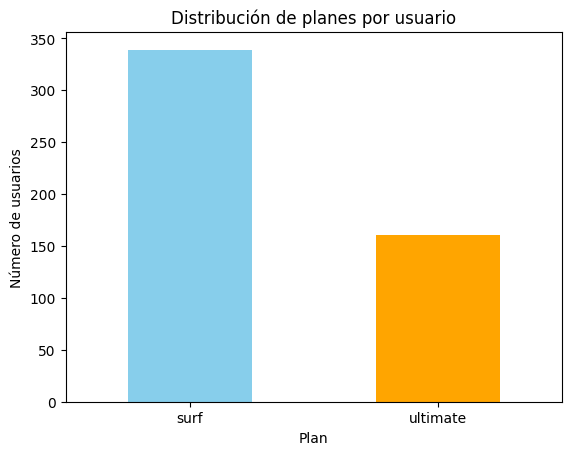

In [32]:
#Visualizar la informacion ocn un grafico de barras
users['plan'].value_counts().plot(kind='bar', color=['skyblue', 'orange'])
plt.title('Distribución de planes por usuario')
plt.xlabel('Plan')
plt.ylabel('Número de usuarios')
plt.xticks(rotation=0)
plt.show()

## Llamadas

In [33]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


In [34]:
# Imprime una muestra de datos para las llamadas
#print(calls.head)  #priemras 5 filas
#calls.tail()       #ultimas 5 filas
#muestra aleatoria de 10 filas
calls.sample(10, random_state=1)

,id,user_id,call_date,duration
106231,1374_327,1374,2018-12-17,1.17
109017,1385_87,1385,2018-10-20,14.02
76096,1268_600,1268,2018-09-24,12.21
106317,1375_219,1375,2018-12-03,7.03
98706,1354_6,1354,2018-10-16,6.21
50517,1182_90,1182,2018-11-18,1.96
13355,1057_234,1057,2018-10-03,0.00
50255,1181_604,1181,2018-12-28,11.65
129376,1465_773,1465,2018-07-27,12.75
51887,1187_80,1187,2018-12-22,14.22


Descripcion de lo que veo:
* No hay valores nulos:
Todas las columnas tienen 137,735 valores no nulos, lo cual es ideal para el análisis.

* Tipos de datos adecuados:
id: tipo object (correcto si es un identificador de llamada).
user_id: tipo int64 (correcto).
call_date: tipo datetime64[ns] (correcto para análisis por fechas).
duration: tipo float64, lo cual es esperable si la duración de la llamada se mide en minutos con decimales.

Problemas y soluciones:
* Duraciones de llamadas con valor 0:
En la muestra aparece al menos un registro con duration = 0.0. Este tipo de registros pueden ser:
Errores del sistema.
Llamadas fallidas o no contestadas.
* Solucion: Revisar cuántas llamadas tienen duración 0 y decidir si se excluyen o no
* El redondeo hacia arriba ya se efectuó y puede validarse en la info generada

### Corregir los datos

In [35]:
#Mostrar el numero total de llamadas con duracion de cero minutos
calls[calls['duration'] == 0].shape[0]

26834

### Enriquecer los datos

In [36]:
#Redondeamos la duración de las llamadas hacia arriba
#np.ceil(): función de NumPy que redondea cada número hacia arriba al entero más próximo.
#Esto asegura que una llamada de 0.2 minutos (12 segundos) se cobre como 1 minuto.
calls['duration'] = np.ceil(calls['duration'])
print(calls.head)

<bound method NDFrame.head of               id  user_id  call_date  duration
0        1000_93     1000 2018-12-27       9.0
1       1000_145     1000 2018-12-27      14.0
2       1000_247     1000 2018-12-27      15.0
3       1000_309     1000 2018-12-28       6.0
4       1000_380     1000 2018-12-30       5.0
...          ...      ...        ...       ...
137730  1499_199     1499 2018-11-21       9.0
137731  1499_200     1499 2018-10-20      11.0
137732  1499_201     1499 2018-09-21       9.0
137733  1499_202     1499 2018-10-10       1.0
137734  1499_203     1499 2018-12-29      14.0

[137735 rows x 4 columns]>


<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Para seguir las reglas de negocio de la empresa se debería aplicar un redondeo hacia arriba de la columna `duration` ya que se menciona que la empresa cobra cómo completo cada fracción de minuto. Esto lo puedes hacer usando `np.ceil`.
   
</div>

## Mensajes

In [37]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
messages.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


In [38]:
# Imprime una muestra de datos para los mensajes
#print(messages.head)  #priemras 5 filas
#messages.tail()       #ultimas 5 filas
#muestra aleatoria de 10 filas
messages.sample(10, random_state=1)


,id,user_id,message_date
12922,1084_162,1084,2018-11-17
55949,1354_99,1354,2018-10-04
19111,1123_180,1123,2018-11-04
46123,1314_11,1314,2018-12-15
72141,1467_473,1467,2018-05-18
58237,1369_38,1369,2018-12-15
55621,1349_433,1349,2018-10-11
18826,1122_55,1122,2018-07-13
64105,1408_230,1408,2018-06-05
6990,1057_314,1057,2018-11-18


Descripcion de lo que veo - informacion general:

* Filas totales: 76,051 mensajes registrados.
* Columnas: 3 columnas (id, user_id, message_date).
* Valores nulos: Ninguna columna tiene valores nulos (Non-Null Count coincide con el total de filas).

Tipos de datos:

* id: tipo object: correcto para un identificador.
* user_id: tipo int64: correcto para identificadores de usuario.
* message_date: tipo datetime64[ns]: correcto para representar fechas.

Descripcion de lo que veo - Muestra de datos:
* Se presentan varios registros de mensajes de distintos usuarios (user_id) con fechas correspondientes en 2018: normal.
* Los valores parecen consistentes: el formato de fecha es correcto, y los identificadores están bien formados. 
* No hay signos de duplicados, aunque creo que esto requiere una verificación más formal.

### Corregir los datos

In [39]:
#Validar si existen datos duplicados
duplicados = messages.duplicated()
print("Cantidad de filas duplicadas:", duplicados.sum())

Cantidad de filas duplicadas: 0


### Enriquecer los datos

In [40]:
#Creamos columna con el valor del mes, con el fin de realizar calculos mas adelante
messages['month'] = messages['message_date'].dt.to_period('M')
print(messages.head())

         id  user_id message_date    month
0  1000_125     1000   2018-12-27  2018-12
1  1000_160     1000   2018-12-31  2018-12
2  1000_223     1000   2018-12-31  2018-12
3  1000_251     1000   2018-12-27  2018-12
4  1000_255     1000   2018-12-26  2018-12


## Internet

In [41]:
# Imprime la información general/resumida sobre el DataFrame de internet

internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


In [42]:
# Imprime una muestra de datos para el tráfico de internet
#print(internet.head)  #priemras 5 filas
#internet.tail()       #ultimas 5 filas
#muestra aleatoria de 10 filas
internet.sample(10, random_state=1)


,id,user_id,session_date,mb_used
13106,1062_76,1062,2018-09-15,225.79
70950,1331_201,1331,2018-09-28,169.69
6195,1035_43,1035,2018-12-27,124.84
2400,1011_140,1011,2018-06-26,0.00
25926,1121_19,1121,2018-12-16,504.92
63187,1291_312,1291,2018-07-08,289.98
16908,1077_28,1077,2018-12-12,465.72
64323,1295_223,1295,2018-12-20,549.30
95470,1445_118,1445,2018-08-13,405.50
55326,1251_137,1251,2018-12-18,285.50


Descripcion de lo que observo - Informacion general:

* Tiene 104,825 registros, sin valores nulos.

Columnas y tipos de datos:
* id: identificador de la sesión - object.
* user_id: identificador del usuario - int64.
* session_date: fecha de la sesión - datetime64[ns].
* mb_used: megabytes usados en la sesión - float64.

Descripcion de lo que observo - Muestra de datos:
* Se observan sesiones con uso de datos muy variables, desde 0.00 MB hasta más de 500 MB.
* Fechas están dentro del año 2018, lo cual es consistente con el resto del proyecto.

Problemas y soluciones:
* Sesiones con 0 MB: Estas sesiones no generan tráfico real. Si son numerosas, pueden distorsionar el promedio de uso - Evaluar si deben eliminarse.
* Valores atípicos (uso muy alto): Si hay sesiones muy grandes (>5 GB en una sola sesión), podrían ser errores o merecen revisión - Analizar la distribución con histogramas o describe().
* Es necesario agrupar los MB por usuario y mes, para luego convertirlos a GB y redondear al alza, como exigen las reglas del negocio

### Corregir los datos

In [43]:
#validar sesiones > a 5 GB
print(internet['mb_used'].describe())

count    104825.000000
mean        366.713701
std         277.170542
min           0.000000
25%         136.080000
50%         343.980000
75%         554.610000
max        1693.470000
Name: mb_used, dtype: float64


El valor max es muy alto comparado con el 75%, probablemente haya outliers, valores atipicos que se alejan considerablemente del conjunto de datos.

In [44]:
outliers = internet[internet['mb_used'] > 1182.4]
print(f"Número de sesiones outlier: {len(outliers)}")

Número de sesiones outlier: 424


Solo el 0.4% de las sesiones son consideradas outliers
Realmente esto NO es representativo: es un número muy pequeño respecto al total.
considero dejarlos datos igual.

### Enriquecer los datos

In [45]:
#filtramos las sesiones con mb_used = 0
zero_sessions = internet[internet['mb_used'] == 0]

#cuantas hay?
zero_sessions.shape[0]

13747

13,1% de usuarios tienen registrado sesiones en 0, para un calculo de sonsumo total de datos es un datos relevante que aporta al gran total, deben eliminarse si el analisis a realizar solo se basará en sesiones con trafico.

## Estudiar las condiciones de las tarifas

In [46]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
print(plans)


   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_fee  usd_per_gb  usd_per_message  usd_per_minute plan_name  \
0               20          10             0.03            0.03      surf   
1               70           7             0.01            0.01  ultimate   

   gb_per_month_included  
0                   15.0  
1                   30.0  


<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Por favor continúa con la resolución de tus ejercicios de lo contrario la revisión no se puede realizar de manera adecuada. Si tienes dudas siempre puedes apoyarte en los grupos de discord o pedir a tu Success Manager por tutorías.
   
</div>

## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [47]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

#Creamos columnas de año y mes a partir de la fecha de llamada
calls['month'] = calls['call_date'].dt.month
calls['year'] = calls['call_date'].dt.year

#Agrupamos por user_id, year, month y contar las llamadas
monthly_calls = calls.groupby(['user_id', 'year', 'month']).size().reset_index(name='calls_count')

#Verificamos el resultado
monthly_calls.head()

,user_id,year,month,calls_count
0,1000,2018,12,16
1,1001,2018,8,27
2,1001,2018,9,49
3,1001,2018,10,65
4,1001,2018,11,64


In [48]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.

#redondeamos cada duracion de llamada hacia arriba
calls['rounded_minutes'] = np.ceil(calls['duration'])

#Agrupamos por user_id, year, month y sumamos los minutos
monthly_minutes = calls.groupby(['user_id', 'year', 'month'])['rounded_minutes'].sum().reset_index()
monthly_minutes.rename(columns={'rounded_minutes': 'minutes_used'}, inplace=True)

#verificamos el resultado
monthly_minutes.head()

,user_id,year,month,minutes_used
0,1000,2018,12,124.0
1,1001,2018,8,182.0
2,1001,2018,9,315.0
3,1001,2018,10,393.0
4,1001,2018,11,426.0


In [49]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

#Creamos columnas de mes y año a partir de message_date
messages['month'] = messages['message_date'].dt.month
messages['year'] = messages['message_date'].dt.year

#Agrupamos por user_id, year, month y contamos los mensajes
monthly_messages = messages.groupby(['user_id', 'year', 'month']).size().reset_index(name='messages_sent')

#verificamos el resultado
monthly_messages.head()

,user_id,year,month,messages_sent
0,1000,2018,12,11
1,1001,2018,8,30
2,1001,2018,9,44
3,1001,2018,10,53
4,1001,2018,11,36


In [50]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

# Extraemos mes y año de la fecha de sesión
internet['month'] = internet['session_date'].dt.month
internet['year'] = internet['session_date'].dt.year

# Agrupamos por usuario, año y mes, y sumar el total de MB usados
monthly_internet = internet.groupby(['user_id', 'year', 'month'])['mb_used'].sum().reset_index()

# Convertimos MB a GB y redondear hacia arriba (según las reglas de Megaline)
monthly_internet['gb_used'] = np.ceil(monthly_internet['mb_used'] / 1024)

# Mostramos las primeras filas
monthly_internet.head()

,user_id,year,month,mb_used,gb_used
0,1000,2018,12,1901.47,2.0
1,1001,2018,8,6919.15,7.0
2,1001,2018,9,13314.82,14.0
3,1001,2018,10,22330.49,22.0
4,1001,2018,11,18504.30,19.0


[Junta los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.]

In [51]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
# Unir llamadas y minutos (por 'user_id', 'year' y 'month')
monthly_usage = pd.merge(monthly_calls, monthly_minutes, on=['user_id', 'year', 'month'], how='outer')

# Unir con los mensajes (por 'user_id', 'year' y 'month')
monthly_usage = pd.merge(monthly_usage, monthly_messages, on=['user_id', 'year', 'month'], how='outer')

# Unir con los datos de Internet (por 'user_id', 'year' y 'month')
monthly_usage = pd.merge(monthly_usage, monthly_internet[['user_id', 'year', 'month', 'gb_used']], 
                         on=['user_id', 'year', 'month'], how='outer')

# Llenar los valores nulos con 0 (si no hay datos de un servicio para ese mes)
monthly_usage.fillna(0, inplace=True)

# Asegurarse de que las columnas numéricas estén en el tipo correcto (puedes convertirlas a enteros si es necesario)
monthly_usage[['calls_count', 'minutes_used', 'messages_sent', 'gb_used']] = monthly_usage[[
    'calls_count', 'minutes_used', 'messages_sent', 'gb_used']].astype(int)

# Ver las primeras filas del DataFrame combinado
monthly_usage.head()

,user_id,year,month,calls_count,minutes_used,messages_sent,gb_used
0,1000,2018,12,16,124,11,2
1,1001,2018,8,27,182,30,7
2,1001,2018,9,49,315,44,14
3,1001,2018,10,65,393,53,22
4,1001,2018,11,64,426,36,19


In [52]:
# Añade la información de la tarifa

# Fusionamos los datos de 'users' con 'plans' según el nombre del plan
users_with_plans = users.merge(plans, left_on='plan', right_on='plan_name', how='left')

# Verificamos la fusión para asegurarnos de que la información de la tarifa fue añadida correctamente
users_with_plans.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,is_active,messages_included,mb_per_month_included,minutes_included,usd_monthly_fee,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,True,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,True,50,15360,500,20,10,0.03,0.03,surf,15.0
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,True,50,15360,500,20,10,0.03,0.03,surf,15.0
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,True,50,15360,500,20,10,0.03,0.03,surf,15.0
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,True,50,15360,500,20,10,0.03,0.03,surf,15.0


[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [53]:
# Paso 1: Unir 'users' con 'plans' para que cada usuario tenga los datos de su plan
users_with_plans = users.merge(plans, left_on='plan', right_on='plan_name', how='left')

# Paso 2: Añadir columna 'join_date' y datos del plan al DataFrame de uso mensual
# Esto permite incorporar la información de tarifas (minutos incluidos, precios, etc.) a cada fila de uso mensual
# Nos aseguramos de tener 'user_id' en ambos para hacer merge
monthly_usage_with_tariff = monthly_usage.merge(users_with_plans, on='user_id', how='left')

# Verificar que la fusión fue exitosa
monthly_usage_with_tariff.head()

,user_id,year,month,calls_count,minutes_used,messages_sent,gb_used,first_name,last_name,age,...,is_active,messages_included,mb_per_month_included,minutes_included,usd_monthly_fee,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,1000,2018,12,16,124,11,2,Anamaria,Bauer,45,...,True,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0
1,1001,2018,8,27,182,30,7,Mickey,Wilkerson,28,...,True,50,15360,500,20,10,0.03,0.03,surf,15.0
2,1001,2018,9,49,315,44,14,Mickey,Wilkerson,28,...,True,50,15360,500,20,10,0.03,0.03,surf,15.0
3,1001,2018,10,65,393,53,22,Mickey,Wilkerson,28,...,True,50,15360,500,20,10,0.03,0.03,surf,15.0
4,1001,2018,11,64,426,36,19,Mickey,Wilkerson,28,...,True,50,15360,500,20,10,0.03,0.03,surf,15.0


In [54]:
# Crear una nueva columna 'area' extrayendo el texto después de la coma (",")
monthly_usage_with_tariff['area'] = monthly_usage_with_tariff['city'].str.split(',').str[1].str.strip()

# Ver los primeros 5 valores de la nueva columna 'area'
print(monthly_usage_with_tariff[['city', 'area']].head())

                                    city    area
0  Atlanta-Sandy Springs-Roswell, GA MSA  GA MSA
1        Seattle-Tacoma-Bellevue, WA MSA  WA MSA
2        Seattle-Tacoma-Bellevue, WA MSA  WA MSA
3        Seattle-Tacoma-Bellevue, WA MSA  WA MSA
4        Seattle-Tacoma-Bellevue, WA MSA  WA MSA


In [55]:
# Calcular los ingresos mensuales por usuario

# Minutos extra (si usa más de lo incluido)
monthly_usage_with_tariff['extra_minutes'] = (
    monthly_usage_with_tariff['minutes_used'] - monthly_usage_with_tariff['minutes_included']
).clip(lower=0)

# Mensajes extra
monthly_usage_with_tariff['extra_messages'] = (
    monthly_usage_with_tariff['messages_sent'] - monthly_usage_with_tariff['messages_included']
).clip(lower=0)

# Datos extra: convertir MB incluidos a GB y redondear exceso hacia arriba
included_gb = monthly_usage_with_tariff['mb_per_month_included'] / 1024
monthly_usage_with_tariff['extra_gb'] = (
    monthly_usage_with_tariff['gb_used'] - included_gb
).clip(lower=0).apply(np.ceil)


# Cálculamos los cargos extra
monthly_usage_with_tariff['cost_extra_minutes'] = monthly_usage_with_tariff['extra_minutes'] * monthly_usage_with_tariff['usd_per_minute']
monthly_usage_with_tariff['cost_extra_messages'] = monthly_usage_with_tariff['extra_messages'] * monthly_usage_with_tariff['usd_per_message']
monthly_usage_with_tariff['cost_extra_gb'] = monthly_usage_with_tariff['extra_gb'] * monthly_usage_with_tariff['usd_per_gb']


# Ingreso mensual total por usuario
monthly_usage_with_tariff['monthly_revenue'] = (
    monthly_usage_with_tariff['usd_monthly_fee'] +
    monthly_usage_with_tariff['cost_extra_minutes'] +
    monthly_usage_with_tariff['cost_extra_messages'] +
    monthly_usage_with_tariff['cost_extra_gb']
)

# Mostramos resultado
monthly_usage_with_tariff[['user_id', 'year', 'month', 'monthly_revenue']].head(20)

,user_id,year,month,monthly_revenue
0,1000,2018,12,70.00
1,1001,2018,8,20.00
2,1001,2018,9,20.00
3,1001,2018,10,90.09
4,1001,2018,11,60.00
5,1001,2018,12,60.00
6,1002,2018,10,20.00
7,1002,2018,11,60.00
8,1002,2018,12,20.00
9,1003,2018,12,158.12


## Estudia el comportamiento de usuario

[Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.]

### Llamadas

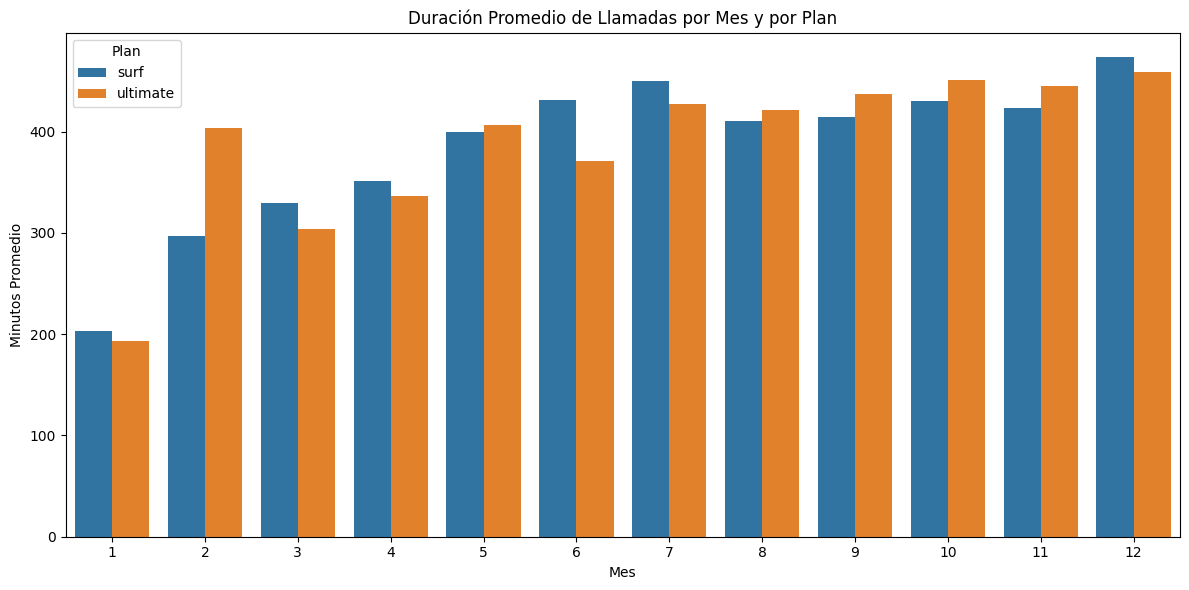

In [56]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

# Agrupar por plan
stats_by_plan = monthly_usage_with_tariff.groupby('plan').agg({
    'monthly_revenue': ['mean', 'sum'],
    'minutes_used': 'mean',
    'messages_sent': 'mean',
    'gb_used': 'mean',
    'extra_minutes': lambda x: (x > 0).mean(),
    'extra_messages': lambda x: (x > 0).mean(),
    'extra_gb': lambda x: (x > 0).mean(),
    'user_id': 'count'
}).round(2)

# Renombrar columnas
stats_by_plan.columns = [
    'avg_monthly_revenue', 'total_revenue',
    'avg_minutes_used', 'avg_messages_sent', 'avg_gb_used',
    'pct_users_extra_minutes', 'pct_users_extra_messages', 'pct_users_extra_gb',
    'user_months_count'
]

stats_by_plan

# Promedio de minutos por plan y mes
avg_minutes_by_month_plan = monthly_usage_with_tariff.groupby(['plan', 'month'])['minutes_used'].mean().reset_index()

# Gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_minutes_by_month_plan, x='month', y='minutes_used', hue='plan')
plt.title('Duración Promedio de Llamadas por Mes y por Plan')
plt.ylabel('Minutos Promedio')
plt.xlabel('Mes')
plt.legend(title='Plan')
plt.tight_layout()
plt.show()

In [57]:
#revisamos el contenido del df completo para validar informacion necesaria

monthly_usage_with_tariff.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                2293 non-null   int64         
 1   year                   2293 non-null   int64         
 2   month                  2293 non-null   int64         
 3   calls_count            2293 non-null   int64         
 4   minutes_used           2293 non-null   int64         
 5   messages_sent          2293 non-null   int64         
 6   gb_used                2293 non-null   int64         
 7   first_name             2293 non-null   object        
 8   last_name              2293 non-null   object        
 9   age                    2293 non-null   int64         
 10  city                   2293 non-null   object        
 11  reg_date               2293 non-null   datetime64[ns]
 12  plan                   2293 non-null   object        
 13  chu

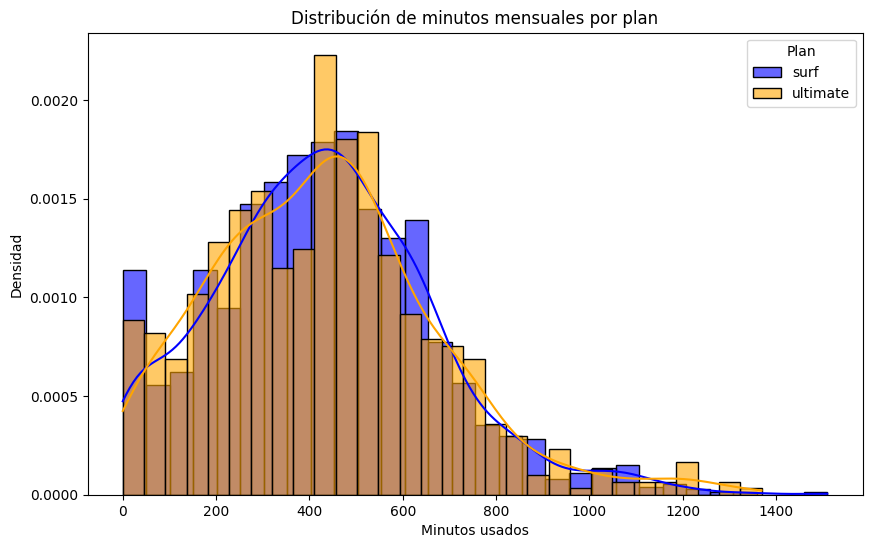

In [58]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

# Filtrar los datos de usuarios activos
df_active = monthly_usage_with_tariff[monthly_usage_with_tariff['is_active']]

# Configurar el tamaño de la figura
plt.figure(figsize=(10,6))

# Crear el histograma para cada plan por separado
sns.histplot(data=df_active[df_active['plan'] == 'surf'], x='minutes_used', kde=True, 
             color='blue', label='surf', bins=30, stat='density', alpha=0.6)
sns.histplot(data=df_active[df_active['plan'] == 'ultimate'], x='minutes_used', kde=True, 
             color='orange', label='ultimate', bins=30, stat='density', alpha=0.6)

# Agregar leyenda y títulos
plt.legend(title='Plan')
plt.title('Distribución de minutos mensuales por plan')
plt.xlabel('Minutos usados')
plt.ylabel('Densidad')

# Mostrar el gráfico
plt.show()

[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

In [59]:
# Calcular la media y varianza de la duración mensual de llamadas
media_minutos = df_active['minutes_used'].mean()
varianza_minutos = df_active['minutes_used'].var()

# Mostrar los resultados
print(f"Media de minutos usados: {media_minutos:.2f}")
print(f"Varianza de minutos usados: {varianza_minutos:.2f}")

Media de minutos usados: 431.03
Varianza de minutos usados: 56992.01


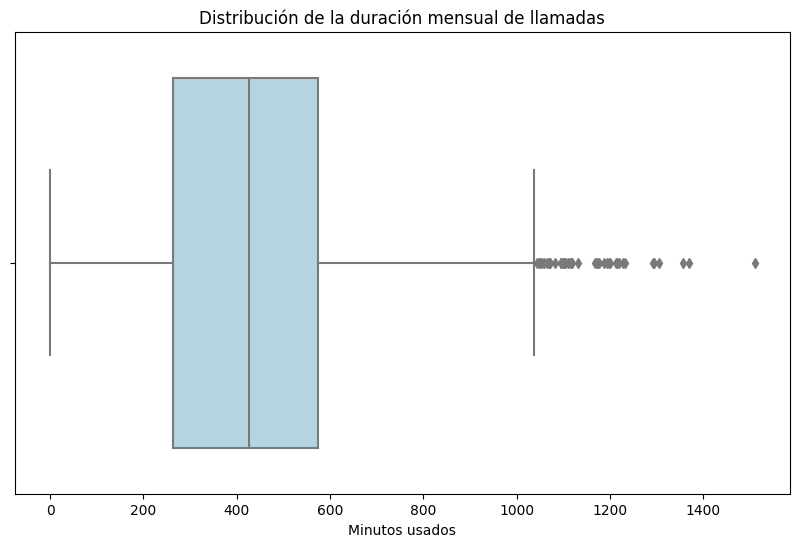

In [60]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

# Configurar el tamaño de la figura
plt.figure(figsize=(10,6))

# Traza el diagrama de caja
sns.boxplot(data=df_active, x='minutes_used', color='lightblue')

# Agregar títulos y etiquetas
plt.title('Distribución de la duración mensual de llamadas')
plt.xlabel('Minutos usados')

# Mostrar el gráfico
plt.show()

[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a las llamadas. ¿Su comportamiento varía en función del plan?]

Duración Promedio de Llamadas
* Ambos planes muestran un incremento gradual en la duración promedio de llamadas a lo largo del año, con valores mínimos en el mes 1 (200 minutos) y máximos en el mes 12 (450 minutos).

Comparativa entre planes:

* En los primeros meses (1-4), el plan Ultimate generalmente muestra mayor duración promedio que el plan Surf.
* A partir del mes 5, los patrones se vuelven más variables, con momentos donde el plan Surf supera al Ultimate (meses 6 y 7).
* En los últimos meses del año (9-12), el plan Ultimate consistentemente supera al Surf en duración promedio.


* Ambos planes muestran una concentración principal alrededor de los 300-500 minutos.
* El plan Ultimate muestra mayor variabilidad, con más usuarios en los extremos (uso muy bajo y uso muy alto).
* El plan Surf muestra una distribución más concentrada alrededor de la media.


* Plan Surf: Los usuarios muestran un comportamiento más predecible y homogéneo, con menos variabilidad en su consumo.
* Plan Ultimate: Los usuarios muestran comportamientos más extremos, tanto de bajo como de alto consumo, sugiriendo un perfil de cliente más diverso.

### Mensajes

In [61]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
monthly_messages_by_plan = monthly_usage_with_tariff.groupby('plan_name')['messages_sent'].mean().round(2)
print(monthly_messages_by_plan)


plan_name
surf        31.16
ultimate    37.55
Name: messages_sent, dtype: float64


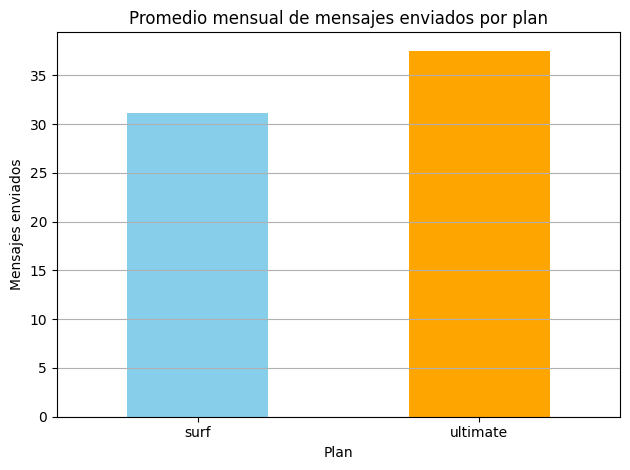

In [62]:
#graficamos
monthly_messages_by_plan.plot(kind='bar', color=['skyblue', 'orange'])
plt.title('Promedio mensual de mensajes enviados por plan')
plt.ylabel('Mensajes enviados')
plt.xlabel('Plan')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Internet

In [63]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
#Calcular el promedio mensual de GB consumidos por plan
avg_gb_by_plan = monthly_usage_with_tariff.groupby('plan_name')['gb_used'].mean().round(2)
print(avg_gb_by_plan)

plan_name
surf        16.67
ultimate    17.31
Name: gb_used, dtype: float64


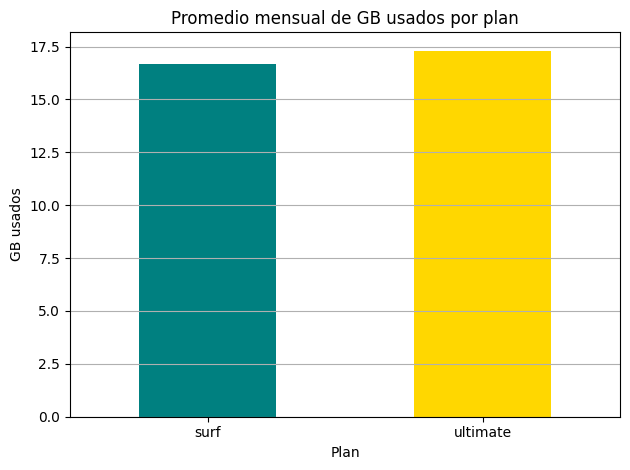

In [64]:
#graficamos
avg_gb_by_plan.plot(kind='bar', color=['teal', 'gold'])
plt.title('Promedio mensual de GB usados por plan')
plt.ylabel('GB usados')
plt.xlabel('Plan')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Conclusiones sobre el comportamiento con respecto a los mensajes:

Los usuarios del plan Ultimate envían en promedio más mensajes por mes que los del plan Surf
Ultimate: 37.55 mensajes/mes Surf: 31.16 mensajes/mes

Aunque la diferencia no es muy grande (alrededor de 6.4 mensajes más en promedio), sí indica una tendencia moderada a un mayor uso del servicio de mensajería entre quienes están suscritos al plan más costoso.

El comportamiento de envío de mensajes sí varía en función del plan Esto sugiere que los usuarios:
Eligen el plan en parte según sus necesidades de comunicación, o bien:
Aprovechan la mayor cantidad de mensajes incluidos en Ultimate (1000 vs 50), lo que les permite enviar más sin temor a costos adicionales.
El límite del plan podría estar influyendo en el comportamiento de los usuarios de Surf Dado que Surf solo incluye 50 mensajes al mes, y el promedio de mensajes enviados (31.16) está relativamente cerca del límite, es posible que los usuarios moderen su uso para evitar cargos adicionales. Esto contrasta con Ultimate, donde el promedio (37.55) está muy por debajo del límite de 1000, indicando mayor holgura y menor preocupación por costos extra.

La diferencia sugiere un perfil de usuario ligeramente distinto por plan

Usuarios de Ultimate pueden ser más intensivos en el uso del servicio, o tienen hábitos de comunicación más activos.
Usuarios de Surf podrían ser más moderados o conscientes del costo por mensaje adicional.

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

In [65]:
# Estadísticas descriptivas de los ingresos por plan
monthly_usage_with_tariff.groupby('plan_name')['monthly_revenue'].describe()

,count,mean,std,min,25%,50%,75%,max
plan_name,,,,,,,,
surf,1573.0,60.706408,55.388042,20.0,20.0,40.36,80.36,590.37
ultimate,720.0,72.313889,11.395108,70.0,70.0,70.00,70.00,182.00


Conclusiones:

Ultimate tiene ingresos promedio mayores que Surf, como era de esperarse, ya que su tarifa base es más alta.

Los ingresos del plan Ultimate son más estables (desviación estándar baja), indicando que la mayoría de los usuarios pagan exactamente la tarifa fija.

Los ingresos del plan Surf son más variables, lo cual sugiere que muchos usuarios exceden los límites del plan básico y generan cargos adicionales.

El ingreso mínimo de Surf es igual a su cuota base ($20), lo que indica usuarios que no consumen más allá del paquete.

El ingreso máximo puede ayudarte a identificar usuarios con uso intensivo, útiles si quieres analizar perfiles de alto consumo.

Conclusiones sobre cómo difieren los ingresos entre los planes Surf y Ultimate:
    
1. Ingresos más altos y estables en Ultimate

* El ingreso promedio mensual por usuario en Ultimate es mayor: $72.31 vs. $60.71.

* La desviación estándar es baja ($11.40), lo que muestra que la mayoría de los usuarios pagan exactamente lo mismo, con pocos cargos adicionales.

2. Ingresos en Surf: más variables y menos predecibles

* Aunque algunos usuarios de Surf generan ingresos muy altos (hasta $590.37), la mayoría pagan mucho menos (mediana: $40.36).

* La alta desviación estándar ($55.39) indica una dispersión significativa en los ingresos mensuales.

3. Estructura tarifaria influye fuertemente en los ingresos

* Ultimate cobra una tarifa plana alta con pocos consumos excedentes.

* Surf cobra una tarifa baja, pero muchos usuarios superan los límites, generando cargos adicionales.

4. Alto potencial de optimización comercial

* Algunos usuarios de Surf pagan más de lo que costaría un plan Ultimate, lo que sugiere que podrían ser redirigidos estratégicamente para maximizar satisfacción y fidelización.

## Prueba las hipótesis estadísticas

In [66]:
# Prueba las hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf
# Filtrar ingresos por plan
surf_revenue = monthly_usage_with_tariff[monthly_usage_with_tariff['plan_name'] == 'surf']['monthly_revenue']
ultimate_revenue = monthly_usage_with_tariff[monthly_usage_with_tariff['plan_name'] == 'ultimate']['monthly_revenue']

# Prueba t de Welch (varianzas desiguales)
t_stat, p_value = ttest_ind(surf_revenue, ultimate_revenue, equal_var=False)

print(f'Estadístico t: {t_stat:.3f}')
print(f'Valor p: {p_value:.3f}')

# Evaluar la hipótesis
alpha = 0.05
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay diferencia significativa entre los ingresos promedio.")
else:
    print("No se puede rechazar la hipótesis nula: no hay evidencia suficiente de una diferencia significativa.")


Estadístico t: -7.952
Valor p: 0.000
Rechazamos la hipótesis nula: hay diferencia significativa entre los ingresos promedio.


In [67]:
# Prueba las hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones
# Filtramos los datos en dos grupos: usuarios de NY-NJ-PA MSA y usuarios de otras regiones
ny_nj_pa_users = monthly_usage_with_tariff[monthly_usage_with_tariff['area'] == 'NY-NJ-PA MSA']
other_areas_users = monthly_usage_with_tariff[monthly_usage_with_tariff['area'] != 'NY-NJ-PA MSA']

# Ingreso mensual (suponiendo que está en la columna 'monthly_revenue')
ny_nj_pa_revenue = ny_nj_pa_users['monthly_revenue']
other_areas_revenue = other_areas_users['monthly_revenue']

# Realizamos la prueba t de Student para muestras independientes
t_stat, p_value = st.ttest_ind(ny_nj_pa_revenue, other_areas_revenue, equal_var=False)

# Imprimimos los resultados
print(f'Estadístico t: {t_stat}')
print(f'Valor p: {p_value}')

# Evaluamos la hipótesis
alpha = 0.05
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay una diferencia significativa entre los ingresos promedio.")
else:
    print("No se puede rechazar la hipótesis nula: no hay evidencia suficiente de una diferencia significativa.")

Estadístico t: -2.1309454999502133
Valor p: 0.0335256158853001
Rechazamos la hipótesis nula: hay una diferencia significativa entre los ingresos promedio.


## Conclusión general

[En esta sección final, enumera tus conclusiones importantes. Asegúrate de que estas abarquen todas las decisiones (suposiciones) importantes que adoptaste y que determinaron la forma elegida para procesar y analizar los datos.]

Conclusiones Generales del Proyecto

1. Propósito del análisis
El objetivo principal fue determinar cuál de las dos tarifas de prepago ofrecidas por Megaline —Surf o Ultimate— genera mayores ingresos promedio y es, por tanto, más rentable. Esta información permitirá orientar mejor las inversiones del presupuesto publicitario.

2. Procesamiento y decisiones clave
Limpieza y transformación de datos: Se integraron múltiples fuentes de datos (llamadas, mensajes, uso de Internet, datos de clientes y planes) para construir un dataframe consolidado (monthly_usage_with_tariff) con métricas mensuales por usuario.

Conversión de unidades: Se estandarizó el consumo de datos de megabytes a gigabytes para facilitar el análisis.

Detección de excedentes: Se calcularon los minutos, mensajes y GB adicionales consumidos respecto al plan contratado para estimar ingresos por sobrecostos.

Cálculo de ingresos mensuales: Se construyó una columna de monthly_revenue que incluye la tarifa base más los ingresos por uso adicional.

3. Comportamiento del cliente según el plan
Mensajes enviados: Los usuarios del plan Ultimate enviaron en promedio más mensajes mensuales (37.6) que los de Surf (31.2).

Consumo de Internet: Los usuarios de Ultimate consumieron también ligeramente más datos (17.3 GB) que los de Surf (16.7 GB).

Comportamiento más intensivo: Esto sugiere que los usuarios de Ultimate tienden a usar más los servicios, probablemente por los mayores límites incluidos.

4. Análisis de ingresos por plan
* Ingreso promedio mensual:

Surf: $60,71

Ultimate: $72,31

* Distribución del ingreso:

Ultimate tiene ingresos más estables (desviación estándar baja) debido a su tarifa plana alta con pocos excedentes.
Surf muestra mayor variabilidad, con algunos usuarios generando ingresos muy altos por sobrecostos.

* Prueba estadística: Se realizó una prueba t de Student que mostró una diferencia significativa entre los ingresos de ambos planes (valor p < 0.05).

5. Impacto geográfico
Se creó una columna area a partir de la ubicación del cliente.

Se comprobó con una prueba estadística que los ingresos de usuarios del área NY-NJ-PA MSA son significativamente diferentes a los del resto del país (valor p ≈ 0.033). Esto podría sugerir un patrón regional que vale la pena investigar más a fondo.

Finalmente:

* Ultimate genera más ingresos promedio por usuario.
* Los usuarios de Ultimate hacen un uso más intensivo de los servicios.
* La estabilidad de ingresos del plan Ultimate es mayor.
* Se recomienda al departamento comercial concentrar el presupuesto publicitario en promocionar el plan Ultimate, especialmente en segmentos y regiones donde se observe mayor propensión al uso intensivo de servicios móviles.